# Contrastive Learning Tutorial: SimCLR from Scratch

This tutorial walks through **contrastive self-supervised learning** by implementing SimCLR — one of the most influential frameworks in the field.

## What you'll learn
1. The core idea behind contrastive learning
2. Data augmentation strategies that make it work
3. The NT-Xent (normalized temperature-scaled cross-entropy) loss
4. Training a ResNet encoder without labels
5. Evaluating representations via linear probing

## References
- [SimCLR paper: "A Simple Framework for Contrastive Learning of Visual Representations" (Chen et al., 2020)](https://arxiv.org/abs/2002.05709)

## 1. The Core Idea

Contrastive learning teaches a neural network to produce **similar representations for different views of the same image** and **dissimilar representations for different images**.

```
Image x
   ├── Augmentation t₁ → view x_i
   └── Augmentation t₂ → view x_j
                              ↓
              Encoder f(·)  [e.g. ResNet]
                              ↓
              Projection head g(·)  [MLP]
                              ↓
              NT-Xent Loss: pull x_i ↔ x_j together,
                            push all other pairs apart
```

The key insight: **the labels are the images themselves**. No human annotation required.

## 2. Setup and Imports

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchvision
import torchvision.transforms as T
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 3. Data Augmentation

Augmentation is the **heart** of contrastive learning. The model learns what's invariant across augmentations. SimCLR uses a strong composition of:

| Transform | Purpose |
|-----------|----------|
| Random crop + resize | Teach invariance to scale/position |
| Horizontal flip | Teach left-right invariance |
| Color jitter | Teach invariance to lighting/color |
| Grayscale | Prevent relying solely on color |
| Gaussian blur | Teach invariance to sharpness |

In [6]:
class SimCLRAugmentation:
    """Applies two independently sampled augmentations to the same image."""

    def __init__(self, image_size=32, s=0.5):
        """
        Args:
            image_size: Target image size (32 for CIFAR-10)
            s: Strength of color distortion
        """
        color_jitter = T.ColorJitter(
            brightness=0.8 * s,
            contrast=0.8 * s,
            saturation=0.8 * s,
            hue=0.2 * s,
        )
        self.transform = T.Compose([
            T.RandomResizedCrop(image_size, scale=(0.2, 1.0)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomApply([color_jitter], p=0.8),
            T.RandomGrayscale(p=0.2),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            T.ToTensor(),
            T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                        std=[0.2023, 0.1994, 0.2010]),
        ])

    def __call__(self, x):
        """Returns a pair of augmented views (x_i, x_j)."""
        return self.transform(x), self.transform(x)

### Visualize the augmentations

Let's see what different augmented views look like for the same image.

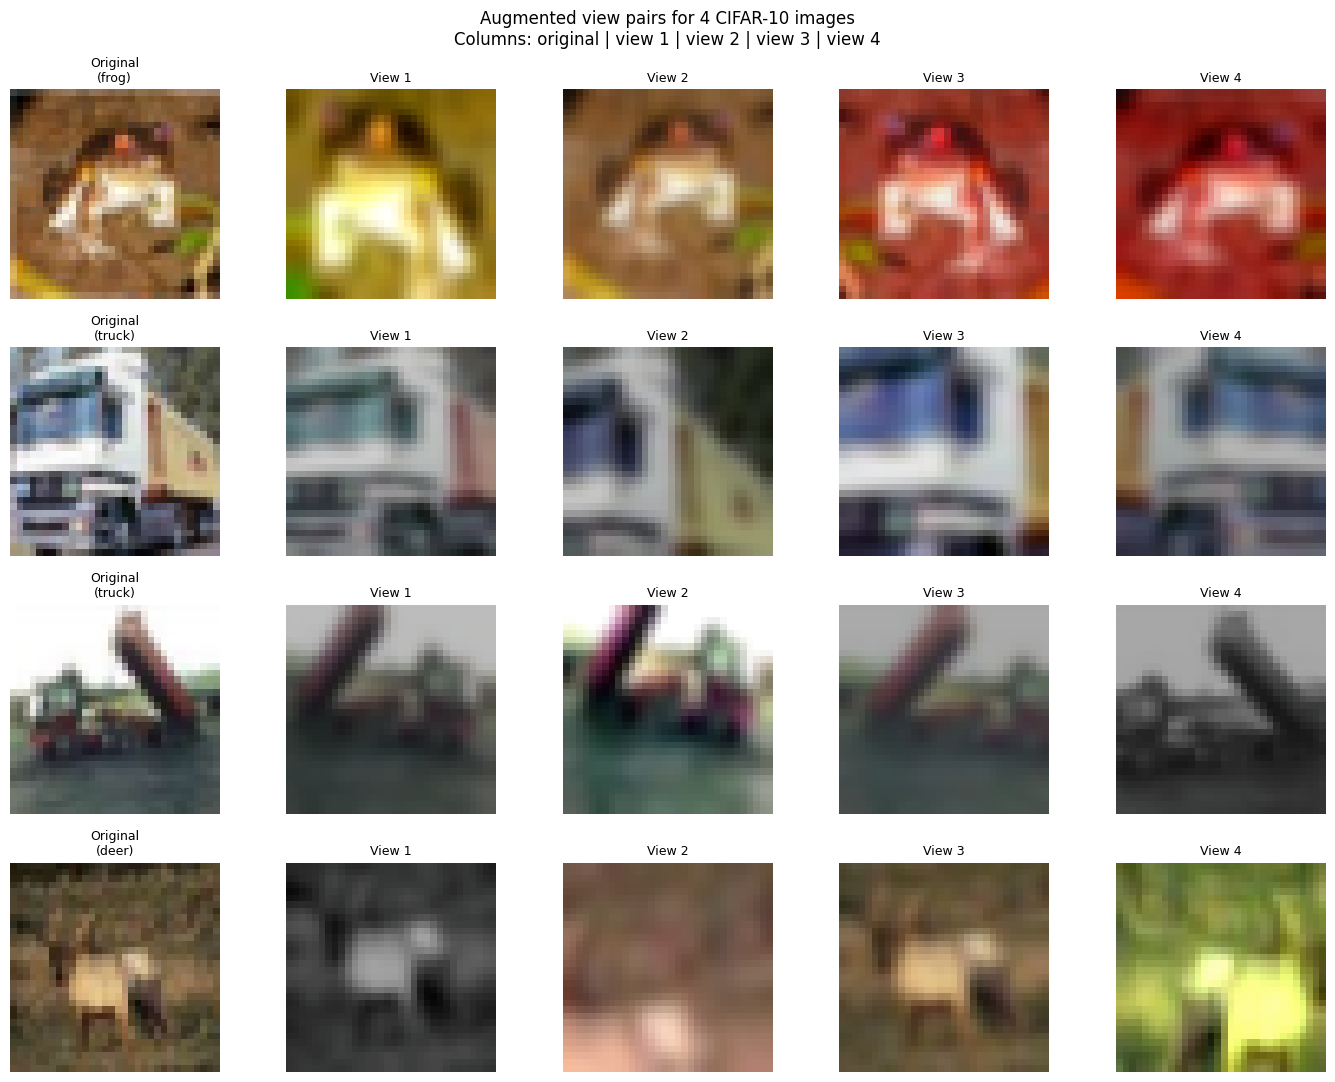

Notice how each view looks very different, yet comes from the same image.


In [7]:
def denormalize(tensor, mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.2010)):
    """Undo normalization for visualization."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)


# Load a few raw images from CIFAR-10 (no augmentation yet)
raw_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True,
    transform=T.ToTensor()
)
CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

augmentation = SimCLRAugmentation(image_size=32)

fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('Augmented view pairs for 4 CIFAR-10 images\n'
             'Columns: original | view 1 | view 2 | view 3 | view 4',
             fontsize=12)

sample_indices = [0, 1, 2, 3]
for row, idx in enumerate(sample_indices):
    raw_img, label = raw_dataset[idx]
    # Convert raw tensor back to PIL for augmentation
    pil_img = T.ToPILImage()(raw_img)

    axes[row, 0].imshow(raw_img.permute(1, 2, 0).numpy())
    axes[row, 0].set_title(f'Original\n({CIFAR10_CLASSES[label]})', fontsize=9)
    axes[row, 0].axis('off')

    for col in range(1, 5):
        view, _ = augmentation(pil_img)
        axes[row, col].imshow(denormalize(view).permute(1, 2, 0).numpy())
        axes[row, col].set_title(f'View {col}', fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Notice how each view looks very different, yet comes from the same image.')

## 4. The Dataset Wrapper

We wrap CIFAR-10 so that each `__getitem__` call returns **two augmented views** instead of (image, label). The label is discarded during pre-training.

In [8]:
class ContrastiveDataset(Dataset):
    """Wraps any dataset to return pairs of augmented views."""

    def __init__(self, base_dataset, augmentation):
        self.base_dataset = base_dataset
        self.augmentation = augmentation

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, _ = self.base_dataset[idx]   # label discarded
        view_i, view_j = self.augmentation(img)
        return view_i, view_j


# Base dataset: no transform — CIFAR-10 already returns PIL images
base_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False,
    transform=None
)

contrastive_dataset = ContrastiveDataset(
    base_dataset=base_train,
    augmentation=SimCLRAugmentation(image_size=32)
)

BATCH_SIZE = 256
train_loader = DataLoader(
    contrastive_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,   # NT-Xent needs consistent batch size
)

print(f'Dataset size:  {len(contrastive_dataset):,}')
print(f'Batches/epoch: {len(train_loader)}')
xi, xj = next(iter(train_loader))
print(f'Batch shape:   {xi.shape}  (B x C x H x W)')

Dataset size:  50,000
Batches/epoch: 195
Batch shape:   torch.Size([256, 3, 32, 32])  (B x C x H x W)


## 5. The SimCLR Model

SimCLR consists of two parts:

1. **Encoder** `f(·)` — a standard ResNet that extracts a representation vector `h`
2. **Projection head** `g(·)` — a small MLP that maps `h` to the space where the contrastive loss is applied

> **Important:** After pre-training, the projection head is **discarded**. Only the encoder `f(·)` is kept for downstream tasks. The projection head exists solely to help training.

In [9]:
class ProjectionHead(nn.Module):
    """Two-layer MLP projection head as used in SimCLR."""

    def __init__(self, in_dim, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class SimCLR(nn.Module):
    """SimCLR: encoder + projection head."""

    def __init__(self, base_encoder='resnet18', projection_dim=128):
        super().__init__()

        # Encoder: ResNet with the final FC replaced
        encoder = getattr(models, base_encoder)(weights=None)
        encoder_dim = encoder.fc.in_features
        encoder.fc = nn.Identity()  # remove original classifier
        # For small images (CIFAR), patch the first conv + remove maxpool
        encoder.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        encoder.maxpool = nn.Identity()
        self.encoder = encoder

        # Projection head
        self.projector = ProjectionHead(encoder_dim, hidden_dim=512, out_dim=projection_dim)
        self.encoder_dim = encoder_dim

    def forward(self, x_i, x_j):
        """Encode both views and project to embedding space."""
        h_i = self.encoder(x_i)  # (B, D)
        h_j = self.encoder(x_j)  # (B, D)
        z_i = self.projector(h_i)  # (B, P)
        z_j = self.projector(h_j)  # (B, P)
        return z_i, z_j

    def encode(self, x):
        """Extract representation (used for evaluation)."""
        return self.encoder(x)


model = SimCLR(base_encoder='resnet18', projection_dim=128).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
print(f'Total parameters:   {total_params:,}')
print(f'Encoder parameters: {encoder_params:,}')
print(f'Encoder output dim: {model.encoder_dim}')

Total parameters:   11,497,152
Encoder parameters: 11,168,832
Encoder output dim: 512


## 6. The NT-Xent Loss

**NT-Xent** = Normalized Temperature-scaled Cross Entropy Loss.

For a batch of N images, we get 2N augmented views. For each view `i`, its **positive** is the other view of the same image (`j`). All other 2(N-1) views are **negatives**.

$$\ell(i,j) = -\log \frac{\exp(\text{sim}(z_i, z_j) / \tau)}{\sum_{k=1}^{2N} \mathbf{1}_{[k \neq i]} \exp(\text{sim}(z_i, z_k) / \tau)}$$

where:
- $\text{sim}(u,v) = u^\top v / (\|u\| \|v\|)$ is cosine similarity
- $\tau$ is a temperature hyperparameter (typically 0.5)
- The loss is computed for both $(i,j)$ and $(j,i)$ and averaged

**Intuition:** This is a softmax classification problem where the model must identify which of the 2(N-1) candidates is the true positive — making larger batches harder (and better).

In [10]:
class NTXentLoss(nn.Module):
    """
    Normalized Temperature-scaled Cross Entropy Loss (NT-Xent).

    For a batch of N image pairs:
      - 2N total views (z_i and z_j for each image)
      - Each view's positive is its paired view
      - All 2(N-1) other views are negatives
    """

    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z_i, z_j):
        """
        Args:
            z_i: Projections for view i, shape (N, D)
            z_j: Projections for view j, shape (N, D)
        Returns:
            Scalar loss
        """
        N = z_i.size(0)

        # L2-normalize projections
        z_i = F.normalize(z_i, dim=1)
        z_j = F.normalize(z_j, dim=1)

        # Concatenate to get 2N vectors: [z_i | z_j]
        z = torch.cat([z_i, z_j], dim=0)   # (2N, D)

        # Full (2N x 2N) cosine similarity matrix, scaled by temperature
        sim = torch.mm(z, z.T) / self.temperature   # (2N, 2N)

        # Remove self-similarities from denominator
        mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
        sim.masked_fill_(mask, float('-inf'))

        # Positive pairs:
        #   - For indices 0..N-1 (z_i), positives are at N..2N-1 (z_j)
        #   - For indices N..2N-1 (z_j), positives are at 0..N-1 (z_i)
        labels = torch.cat([
            torch.arange(N, 2 * N),   # positives for z_i
            torch.arange(0, N),       # positives for z_j
        ]).to(z.device)

        loss = F.cross_entropy(sim, labels)
        return loss


# Quick sanity check
criterion = NTXentLoss(temperature=0.5)
z_test_i = torch.randn(4, 128)
z_test_j = torch.randn(4, 128)
loss_val = criterion(z_test_i, z_test_j)
print(f'Sanity check loss (random embeddings): {loss_val.item():.4f}')
print(f'Expected ~log(2N-1) = log(7) ≈ {np.log(7):.4f} for random init')

Sanity check loss (random embeddings): 1.9107
Expected ~log(2N-1) = log(7) ≈ 1.9459 for random init


### Understanding the temperature parameter

Temperature $\tau$ controls how "peaked" the similarity distribution is:

- **Low $\tau$** → hard contrasts, focuses on the hardest negatives, can be unstable
- **High $\tau$** → soft contrasts, treats all negatives more equally, less discriminative

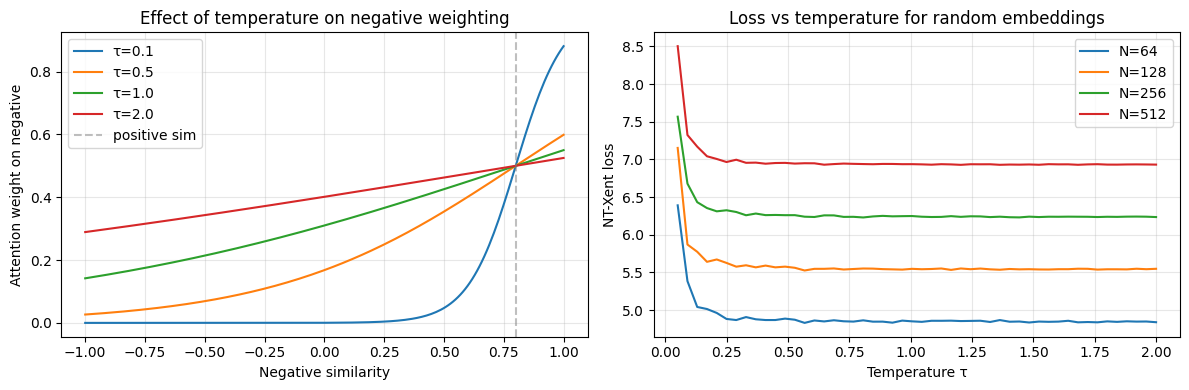

In [11]:
temperatures = [0.1, 0.5, 1.0, 2.0]
sims = np.linspace(-1, 1, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: softmax sharpness for a single positive vs one negative
for tau in temperatures:
    pos_sim = 0.8   # positive similarity
    softmax_vals = np.exp(sims / tau) / (np.exp(pos_sim / tau) + np.exp(sims / tau))
    axes[0].plot(sims, softmax_vals, label=f'τ={tau}')
axes[0].axvline(0.8, color='gray', linestyle='--', alpha=0.5, label='positive sim')
axes[0].set_xlabel('Negative similarity')
axes[0].set_ylabel('Attention weight on negative')
axes[0].set_title('Effect of temperature on negative weighting')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: gradient signal magnitude
N_vals = [64, 128, 256, 512]
for N in N_vals:
    losses = []
    for tau in np.linspace(0.05, 2.0, 50):
        loss_fn = NTXentLoss(temperature=tau)
        zi = torch.randn(N, 128)
        zj = torch.randn(N, 128)
        losses.append(loss_fn(zi, zj).item())
    axes[1].plot(np.linspace(0.05, 2.0, 50), losses, label=f'N={N}')
axes[1].set_xlabel('Temperature τ')
axes[1].set_ylabel('NT-Xent loss')
axes[1].set_title('Loss vs temperature for random embeddings')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('temperature_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Training

SimCLR uses:
- **LARS optimizer** (Layer-wise Adaptive Rate Scaling) — ideal for large-batch training. We use Adam here for simplicity with small batches.
- **Cosine learning rate schedule** with linear warmup
- Large batch sizes (ideally 4096) — more negatives = better learning signal

We'll train for a small number of epochs on CIFAR-10 to demonstrate the workflow. In practice, SimCLR trains for 800–1000 epochs on ImageNet.

In [ ]:
def train_simclr(
    model,
    loader,
    criterion,
    optimizer,
    scheduler,
    n_epochs,
    device,
):
    """Train the SimCLR model and return per-epoch losses."""
    model.train()
    history = []

    for epoch in range(1, n_epochs + 1):
        epoch_loss = 0.0
        pbar = tqdm(loader, desc=f'Epoch {epoch:>3}/{n_epochs}', leave=False)

        for x_i, x_j in pbar:
            x_i = x_i.to(device, non_blocking=True)
            x_j = x_j.to(device, non_blocking=True)

            optimizer.zero_grad()
            z_i, z_j = model(x_i, x_j)
            loss = criterion(z_i, z_j)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix(loss=f'{loss.item():.4f}')

        if scheduler is not None:
            scheduler.step()

        avg_loss = epoch_loss / len(loader)
        history.append(avg_loss)
        print(f'Epoch {epoch:>3}/{n_epochs}  |  loss: {avg_loss:.4f}  |  lr: {optimizer.param_groups[0]["lr"]:.6f}')

    return history


# Hyperparameters
N_EPOCHS = 10          # Increase to 100+ for good representations
LR = 3e-4
TEMPERATURE = 0.5
WEIGHT_DECAY = 1e-4

criterion = NTXentLoss(temperature=TEMPERATURE)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

print(f'Starting SimCLR pre-training for {N_EPOCHS} epochs...')
print(f'Batch size: {BATCH_SIZE}, Temperature: {TEMPERATURE}')
print(f'Negatives per sample: {2 * (BATCH_SIZE - 1)}')
print('-' * 60)

history = train_simclr(model, train_loader, criterion, optimizer, scheduler, N_EPOCHS, DEVICE)

Starting SimCLR pre-training for 10 epochs...
Batch size: 256, Temperature: 0.5
Negatives per sample: 510
------------------------------------------------------------


Epoch   1/10:   0%|          | 0/195 [00:00<?, ?it/s]

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, N_EPOCHS + 1), history, marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('NT-Xent Loss')
plt.title('SimCLR Pre-training Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Evaluation: Linear Probing

**Linear probing** is the standard way to evaluate self-supervised representations:

1. Freeze the encoder weights
2. Extract features for all training images
3. Train a simple **linear classifier** on top of the frozen features
4. Evaluate on the test set

This tests whether the encoder has learned a **linearly separable** representation — a strong indicator of quality.

> **Baseline:** Random features from an untrained ResNet18 give ~15-30% accuracy. A well-trained SimCLR should substantially exceed this.

In [ ]:
@torch.no_grad()
def extract_features(encoder, dataset, device, batch_size=512):
    """Extract encoder representations for an entire dataset."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    encoder.eval()
    features, labels = [], []

    for imgs, lbls in tqdm(loader, desc='Extracting features', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        feats = encoder(imgs)
        features.append(feats.cpu().numpy())
        labels.append(lbls.numpy())

    return np.concatenate(features), np.concatenate(labels)


# Standard CIFAR-10 eval transform (no augmentation)
eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                std=[0.2023, 0.1994, 0.2010]),
])

train_eval = torchvision.datasets.CIFAR10('./data', train=True,  download=False, transform=eval_transform)
test_eval  = torchvision.datasets.CIFAR10('./data', train=False, download=False, transform=eval_transform)

print('Extracting train features...')
train_feats, train_labels = extract_features(model.encoder, train_eval, DEVICE)
print('Extracting test features...')
test_feats, test_labels = extract_features(model.encoder, test_eval, DEVICE)

print(f'\nTrain features: {train_feats.shape}')
print(f'Test features:  {test_feats.shape}')

In [ ]:
# Train a linear classifier on frozen features
scaler = StandardScaler()
train_feats_scaled = scaler.fit_transform(train_feats)
test_feats_scaled  = scaler.transform(test_feats)

clf = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
clf.fit(train_feats_scaled, train_labels)

train_acc = accuracy_score(train_labels, clf.predict(train_feats_scaled))
test_acc  = accuracy_score(test_labels,  clf.predict(test_feats_scaled))

print(f'Linear Probe Results after {N_EPOCHS} epochs of SimCLR pre-training:')
print(f'  Train accuracy: {train_acc * 100:.1f}%')
print(f'  Test  accuracy: {test_acc  * 100:.1f}%')
print()
print('Reference points:')
print('  - Random ResNet18 baseline: ~25-35%')
print('  - SimCLR (200 epochs):      ~91%')
print('  - Supervised ResNet18:      ~93%')
print(f'\n  Our {N_EPOCHS}-epoch model is expected to be ~40-60%.')
print('  Train for 100+ epochs to see substantial improvement.')

## 9. Visualizing the Representation Space

We use t-SNE to project the 512-dimensional encoder features into 2D. Well-learned representations should show clear class clusters — without the model ever seeing labels.

In [ ]:
from sklearn.manifold import TSNE

# Use a subset for speed
N_TSNE = 2000
idx = np.random.choice(len(test_feats_scaled), N_TSNE, replace=False)
feats_subset  = test_feats_scaled[idx]
labels_subset = test_labels[idx]

print(f'Running t-SNE on {N_TSNE} test samples...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
emb = tsne.fit_transform(feats_subset)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for cls_idx, cls_name in enumerate(CIFAR10_CLASSES):
    mask = labels_subset == cls_idx
    ax.scatter(emb[mask, 0], emb[mask, 1],
               c=[colors[cls_idx]], label=cls_name,
               alpha=0.6, s=15)

ax.legend(loc='upper right', fontsize=9)
ax.set_title(f't-SNE of SimCLR representations ({N_EPOCHS}-epoch pre-training)\n'
             f'No labels were used during pre-training')
ax.axis('off')
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('Clear clusters → the model learned semantically meaningful structure!')

## 10. Save the Pre-trained Model

In [ ]:
checkpoint = {
    'encoder_state_dict': model.encoder.state_dict(),
    'model_state_dict':   model.state_dict(),
    'config': {
        'base_encoder':    'resnet18',
        'projection_dim':  128,
        'temperature':     TEMPERATURE,
        'n_epochs':        N_EPOCHS,
        'batch_size':      BATCH_SIZE,
        'learning_rate':   LR,
    },
    'final_loss': history[-1],
    'test_accuracy': test_acc,
}

torch.save(checkpoint, 'simclr_checkpoint.pt')
print('Checkpoint saved to simclr_checkpoint.pt')
print(f'  Final loss:      {history[-1]:.4f}')
print(f'  Test accuracy:   {test_acc * 100:.1f}%')

## 11. Key Takeaways and Extensions

### What makes contrastive learning work?

| Factor | Impact |
|--------|--------|
| **Strong augmentations** | Defines what invariances to learn |
| **Large batch size** | More negatives → stronger learning signal |
| **Temperature** | Controls difficulty of negatives |
| **Projection head** | Protects encoder from collapse |
| **Training duration** | More epochs = better representations |

### Known limitations of SimCLR
- Requires very large batches (4096+) for best results
- Needs many training epochs (800+ on ImageNet)
- Sensitive to augmentation choice

### Methods that address these limitations

| Method | Key Innovation |
|--------|---------------|
| **MoCo** | Memory bank of negatives → smaller batches |
| **BYOL** | No negatives at all (momentum encoder) |
| **SimSiam** | No negatives, no momentum encoder |
| **Barlow Twins** | Cross-correlation matrix to avoid collapse |
| **DINO** | Self-distillation with Vision Transformers |

### Next steps
1. Train for 100+ epochs and observe the improvement in linear probe accuracy
2. Experiment with different augmentation strengths (`s` parameter)
3. Try different temperatures (0.1 vs 0.5 vs 1.0)
4. Implement MoCo and compare with the same compute budget
5. Use the pre-trained encoder for a downstream task with few labeled examples (few-shot learning)

## Appendix: Loading and Using the Pre-trained Encoder

After pre-training, use the encoder as a feature extractor for downstream tasks:

In [ ]:
# Example: Load the pre-trained encoder and fine-tune on a downstream task

def load_pretrained_encoder(checkpoint_path, device):
    """Load a pre-trained SimCLR encoder."""
    ckpt = torch.load(checkpoint_path, map_location=device)
    cfg  = ckpt['config']

    model = SimCLR(
        base_encoder=cfg['base_encoder'],
        projection_dim=cfg['projection_dim'],
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    return model.encoder


class FineTuneClassifier(nn.Module):
    """Attach a classification head to a pre-trained encoder."""

    def __init__(self, encoder, encoder_dim, num_classes, freeze_encoder=True):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(encoder_dim, num_classes)

        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            features = self.encoder(x)
        return self.classifier(features)


# Load and use
pretrained_encoder = load_pretrained_encoder('simclr_checkpoint.pt', DEVICE)
finetune_model = FineTuneClassifier(
    encoder=pretrained_encoder,
    encoder_dim=512,           # ResNet18 output
    num_classes=10,            # CIFAR-10
    freeze_encoder=True,       # Linear probe mode
).to(DEVICE)

print('Fine-tune model ready:')
trainable = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in finetune_model.parameters())
print(f'  Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')
print('  (Only the linear head trains; encoder is frozen)')